In [46]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open("solusdt_5m.json") as f:
    data=json.load(f)

print(len(data[0]))
print(data[0])      

12
[1775334600000, '80.80000000', '80.81000000', '80.73000000', '80.76000000', '863.87500000', 1775334899999, '69781.65554000', 600, '304.61000000', '24606.99232000', '0']


In [47]:
df = pd.DataFrame(data)   # 👈 YOU MISSED THIS STEP
df = df.iloc[:, :6] # Keep only first 6 columns (0 to 5)

In [48]:
# Keep only first 6 columns of each row
data6 = [row[:6] for row in data]

df = pd.DataFrame(data6, columns=["timestamp","open","high","low","close","volume"])

# Convert numeric columns
for col in ["open","high","low","close","volume"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.head())
print(len(df))

       timestamp   open   high    low  close    volume
0  1775334600000  80.80  80.81  80.73  80.76   863.875
1  1775334900000  80.76  80.83  80.76  80.82  1684.196
2  1775335200000  80.82  80.85  80.80  80.80   904.538
3  1775335500000  80.81  80.83  80.78  80.79  1491.124
4  1775335800000  80.80  80.80  80.73  80.76  5574.353
500


In [49]:
print(df.head(10))

       timestamp   open   high    low  close     volume
0  1775334600000  80.80  80.81  80.73  80.76    863.875
1  1775334900000  80.76  80.83  80.76  80.82   1684.196
2  1775335200000  80.82  80.85  80.80  80.80    904.538
3  1775335500000  80.81  80.83  80.78  80.79   1491.124
4  1775335800000  80.80  80.80  80.73  80.76   5574.353
5  1775336100000  80.76  80.81  80.75  80.81   6739.256
6  1775336400000  80.80  80.88  80.80  80.84   7355.472
7  1775336700000  80.84  80.99  80.83  80.93  35163.180
8  1775337000000  80.92  80.93  80.76  80.79  18325.712
9  1775337300000  80.80  80.88  80.77  80.87  32419.298


In [50]:
df.set_index('timestamp',inplace=True)

In [51]:
for col in ['open','high','low','close','volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    

In [52]:
df = df.dropna().reset_index(drop=True)

In [53]:
df=df.ffill()

In [54]:
df['return']=df['close'].pct_change()

In [55]:
df['target']=df['return'].shift(-1)

In [56]:
df['return_1']=df['return'].shift(1)
df['return_2']=df['return'].shift(2)
df['return_3']=df['return'].shift(3)

In [57]:
print(df)

      open   high    low  close     volume    return    target  return_1  \
0    80.80  80.81  80.73  80.76    863.875       NaN  0.000743       NaN   
1    80.76  80.83  80.76  80.82   1684.196  0.000743 -0.000247       NaN   
2    80.82  80.85  80.80  80.80    904.538 -0.000247 -0.000124  0.000743   
3    80.81  80.83  80.78  80.79   1491.124 -0.000124 -0.000371 -0.000247   
4    80.80  80.80  80.73  80.76   5574.353 -0.000371  0.000619 -0.000124   
..     ...    ...    ...    ...        ...       ...       ...       ...   
495  82.35  82.47  82.29  82.40   6618.469  0.000607  0.000607  0.000121   
496  82.41  82.60  82.40  82.45  12650.714  0.000607  0.000121  0.000607   
497  82.45  82.48  82.34  82.46   3808.050  0.000121 -0.002668  0.000607   
498  82.46  82.81  82.19  82.24  17292.854 -0.002668  0.001581  0.000121   
499  82.24  82.39  82.24  82.37   4097.488  0.001581       NaN -0.002668   

     return_2  return_3  
0         NaN       NaN  
1         NaN       NaN  
2        

In [58]:
df['SMA_5']=df['close'].rolling(5).mean()
df['SMA_10']=df['close'].rolling(10).mean()

df['volatility']=df['return'].rolling(10).std()

In [59]:
df=df.dropna().reset_index(drop=True)

In [60]:
y=df['target']
X=df[['return_1','return_2','return_3','SMA_5','SMA_10','volatility']]


In [61]:
split=int(len(df)*0.7)

In [62]:
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

In [63]:
X_train_np=X_train.astype(float).to_numpy()
y_train_np=y_train.astype(float).to_numpy()
X_test_np=X_test.astype(float).to_numpy()
y_test_np=y_test.astype(float).to_numpy()

In [64]:
XtX=X_train_np.T.dot(X_train_np)
XtX_inv=np.linalg.pinv(XtX)
Xty=X_train_np.T.dot(y_train_np)
beta=XtX_inv.dot(Xty)
print("Coefficients:",beta)

Coefficients: [ 8.45956291e-02  1.21836407e-01 -9.17745334e-02 -4.04690560e-05
  3.81994862e-05  1.71584766e-01]


In [65]:
y_pred=X_test_np.dot(beta)

residuals=y_test_np-y_pred
ss_res=np.sum(residuals**2)
ss_tot=np.sum((y_test_np-np.mean(y_test_np))**2)
mse=np.mean((y_test_np-y_pred)**2)
print("MSE:",mse)
print("RMSE:",np.sqrt(mse))

MSE: 2.1241333710634535e-06
RMSE: 0.0014574406921255675


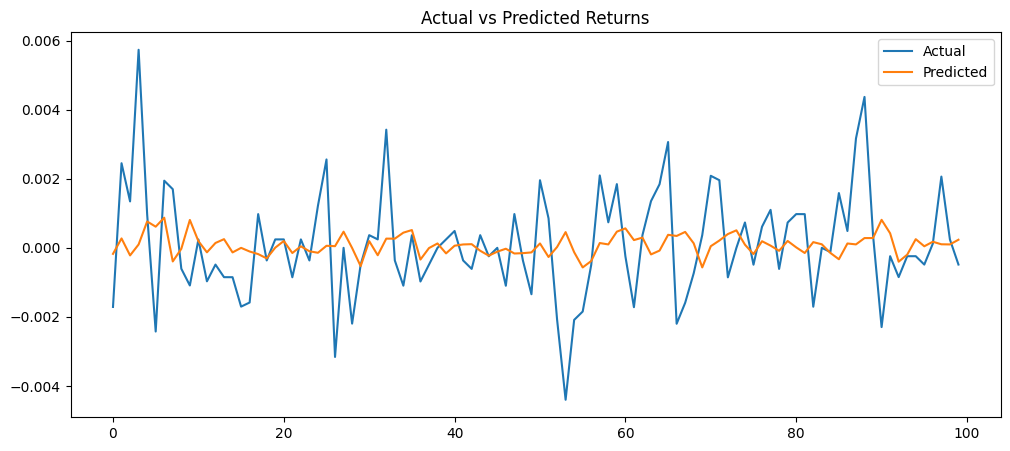

Directional Accuracy: 0.5170068027210885


In [66]:
plt.figure(figsize=(12,5))
plt.plot(y_test_np[:100],label='Actual')
plt.plot(y_pred[:100],label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Returns')
plt.show()

direction_actual=np.sign(y_test_np)
direction_pred=np.sign(y_pred)
accuracy=np.mean(direction_actual==direction_pred)
print("Directional Accuracy:",accuracy)